# 19 · FNSPID momentum with sentiment risk brakes

**Question.** Can the one corrected FNSPID text relationship — an unusually
high negative-story share forecasts next-session *risk* — improve an
independently justified, slow price-momentum book when sentiment is used only
to reduce exposure?

This is deliberately not another standalone sentiment rank. The incumbent
sentiment-only strategies fail transaction costs, while the 12-minus-1-month
momentum baseline is price-only and monthly. The overlay is allowed to move
capital to cash but never to add leverage.

**Evidence status.** The rule below was written before this notebook calculated
either development or evaluation returns. The 2020–2023 chronological
evaluation block has nevertheless been opened by earlier dissertation work,
so this remains exploratory rather than pristine confirmation. No result in
this notebook may be tuned and rerun on the same block.

## Frozen design and success criteria

- **Spine:** FNSPID only; no LSEG rows are pooled.
- **Independent baseline:** monthly equal-weight dollar-neutral top/bottom
  decile of 252-to-21-session adjusted-open momentum. The first session of
  each calendar month forms the book; the book is held on the dense calendar.
- **Risk flag:** `negative_share == 1` and at least two stories on the mapped
  firm-session. The existing conservative date-only mapping makes that signal
  available at the session open whose return is earned.
- **Overlay family (two tests):**
  1. `symmetric_brake`: remove any flagged held name for one session;
  2. `long_brake`: remove only flagged long positions.
- **Neutrality:** after removals, both legs are scaled *down* to the smaller
  surviving gross. Gross exposure can fall below one; it can never increase.
- **Outcome:** dense market-adjusted open-to-open return. A dollar-neutral base
  makes the market subtraction immaterial, while it protects the invariant if
  an implementation error creates net exposure.
- **Costs:** 10 bps per side under half-L1 turnover, charged on entries,
  transitions, re-entries, and final liquidation. Cost curve: 0/1/2/5/10 bps.
- **Split:** development through 2019-12-31; evaluation from 2020-01-01 through
  the last FNSPID signal session. No held return crosses the development end.
- **Inference:** paired challenger-minus-baseline mean daily net return, 20-day
  circular block bootstrap, 4,999 replications, seed 20260805; BH at q=0.05
  across the two overlays within each split.
- **Alpha gate:** positive net Sharpe, break-even at least 10 bps/side, and a
  positive lower 95% block-bootstrap bound on the arm's mean net return.
- **Useful-overlay gate:** evaluation net Sharpe at least 0.10 above baseline,
  less severe maximum drawdown, break-even at least 10 bps/side, positive net
  Sharpe, and a BH-surviving paired net-mean improvement.

Volatility, drawdown, exposure reduction, yearly stability and gross results
are diagnostics. They do not replace the declared net-return estimand.

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "final_experiments").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.panel import (  # noqa: E402
    DEFAULT_PRICE_ZIP,
    FROZEN_DEV_END,
    FROZEN_EVAL_START,
    load_adjusted_open_prices,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    MomentumOverlayConfig,
    apply_sentiment_brake,
    backtest_weight_panel,
    build_monthly_momentum_weights,
    build_negative_risk_flags,
    paired_block_bootstrap_difference,
    reprice_daily,
    summarize_weight_backtest,
)
from final_experiments.lib.strategy import build_daily_ar_panel  # noqa: E402

SEED = 20260805
CONFIG = MomentumOverlayConfig(
    lookback_sessions=252,
    skip_sessions=21,
    tail_fraction=0.10,
    min_universe=100,
    cost_bps_per_side=10.0,
    bootstrap_block_length=20,
    bootstrap_replications=4_999,
    random_seed=SEED,
)
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
ARMS = ("baseline", "symmetric_brake", "long_brake")
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"
OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "19_fnspid_sentiment_risk_overlay"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()

display(CONFIG)

MomentumOverlayConfig(lookback_sessions=252, skip_sessions=21, tail_fraction=0.1, min_universe=100, cost_bps_per_side=10.0, bootstrap_block_length=20, bootstrap_replications=4999, random_seed=20260805)

## Load the frozen FNSPID artifacts

Only aggregate schema and coverage are displayed. Headline text is neither
loaded nor emitted.

In [2]:
firm_day = pd.read_parquet(AGG_PATH)
firm_day["session_date"] = pd.to_datetime(firm_day["session_date"]).dt.normalize()
symbols = set(firm_day["symbol"].astype(str).str.upper().unique())
prices, missing_prices = load_adjusted_open_prices(
    DEFAULT_PRICE_ZIP,
    symbols,
    market_symbol="SPY",
)
daily_ar = build_daily_ar_panel(prices, market_symbol="SPY")
daily_ar["session_date"] = pd.to_datetime(daily_ar["session_date"]).dt.normalize()
daily_ar["return_end_date"] = pd.to_datetime(daily_ar["return_end_date"]).dt.normalize()

evaluation_end = firm_day["session_date"].max()
dev_returns = daily_ar.loc[
    daily_ar["session_date"].le(pd.Timestamp(FROZEN_DEV_END))
    & daily_ar["return_end_date"].le(pd.Timestamp(FROZEN_DEV_END))
].copy()
eval_returns = daily_ar.loc[
    daily_ar["session_date"].ge(pd.Timestamp(FROZEN_EVAL_START))
    & daily_ar["session_date"].le(evaluation_end)
].copy()
dev_sessions = pd.DatetimeIndex(sorted(dev_returns["session_date"].unique()))
eval_sessions = pd.DatetimeIndex(sorted(eval_returns["session_date"].unique()))

coverage = pd.DataFrame(
    [
        {
            "firm_days": len(firm_day),
            "symbols": firm_day["symbol"].nunique(),
            "first_signal_session": firm_day["session_date"].min(),
            "last_signal_session": evaluation_end,
            "development_return_sessions": len(dev_sessions),
            "evaluation_return_sessions": len(eval_sessions),
            "missing_price_symbols": len(missing_prices),
        }
    ]
)
display(coverage)

,firm_days,symbols,first_signal_session,last_signal_session,development_return_sessions,evaluation_return_sessions,missing_price_symbols
0,715546,570,2011-01-03,2023-12-18,2263,998,0


## Build the price-only baseline and the frozen sentiment flags

Formation diagnostics verify that the momentum endpoint predates formation by
21 sessions. The flag threshold is not selected using returns.

In [3]:
dev_base_weights, dev_formations = build_monthly_momentum_weights(
    prices,
    dev_sessions,
    config=CONFIG,
)
eval_base_weights, eval_formations = build_monthly_momentum_weights(
    prices,
    eval_sessions,
    config=CONFIG,
)
risk_flags = build_negative_risk_flags(
    firm_day,
    negative_share_threshold=1.0,
    min_articles=2,
)

formation_summary = pd.DataFrame(
    [
        {
            "split": split,
            "formations": int(formations["status"].eq("formed").sum()),
            "min_universe": int(formations.loc[formations["status"].eq("formed"), "n_universe"].min()),
            "median_universe": float(formations.loc[formations["status"].eq("formed"), "n_universe"].median()),
            "max_skip_violation": int(
                (
                    formations.loc[formations["status"].eq("formed"), "lookback_end"]
                    >= formations.loc[formations["status"].eq("formed"), "formation_date"]
                ).sum()
            ),
        }
        for split, formations in (("development", dev_formations), ("evaluation", eval_formations))
    ]
)
flag_summary = pd.DataFrame(
    [
        {
            "split": split,
            "flagged_firm_sessions": int(risk_flags["session_date"].isin(sessions).sum()),
            "flagged_sessions": int(risk_flags.loc[risk_flags["session_date"].isin(sessions), "session_date"].nunique()),
        }
        for split, sessions in (("development", dev_sessions), ("evaluation", eval_sessions))
    ]
)
display(formation_summary)
display(flag_summary)

,split,formations,min_universe,median_universe,max_skip_violation
0,development,96,543,560.0,0
1,evaluation,48,535,535.0,0


,split,flagged_firm_sessions,flagged_sessions
0,development,9860,2132
1,evaluation,2122,772


## Apply the two brakes

The output retains the base weight and an explicit `brake_applied` flag so the
exposure mechanism is auditable before portfolio returns are interpreted.

In [4]:
weight_paths: dict[str, dict[str, pd.DataFrame]] = {}
for split, base in (("development", dev_base_weights), ("evaluation", eval_base_weights)):
    weight_paths[split] = {
        "baseline": base.assign(
            base_weight=base["weight"],
            risk_flag=False,
            brake_applied=False,
            overlay_mode="baseline",
        ),
        "symmetric_brake": apply_sentiment_brake(base, risk_flags, mode="symmetric"),
        "long_brake": apply_sentiment_brake(base, risk_flags, mode="long_only"),
    }

activity_rows = []
for split, arms in weight_paths.items():
    for arm, frame in arms.items():
        gross_by_day = frame.groupby("session_date")["weight"].apply(lambda values: values.abs().sum())
        activity_rows.append(
            {
                "split": split,
                "arm": arm,
                "sessions": int(frame["session_date"].nunique()),
                "braked_position_sessions": int(frame["brake_applied"].sum()),
                "sessions_with_brake": int(frame.loc[frame["brake_applied"], "session_date"].nunique()),
                "mean_gross_exposure": float(gross_by_day.mean()),
                "minimum_gross_exposure": float(gross_by_day.min()),
            }
        )
activity = pd.DataFrame(activity_rows)
display(activity)

,split,arm,sessions,braked_position_sessions,sessions_with_brake,mean_gross_exposure,minimum_gross_exposure
0,development,baseline,2011,0,0,1.000000,1.000000
1,development,symmetric_brake,2011,2105,1264,0.983918,0.907407
2,development,long_brake,2011,912,696,0.991786,0.909091
3,evaluation,baseline,998,0,0,1.000000,1.000000
4,evaluation,symmetric_brake,998,463,328,0.992448,0.842105
5,evaluation,long_brake,998,210,182,0.996100,0.929825


## Backtest all three frozen arms

Development and evaluation use separate books and exact split-safe return
calendars. Evaluation is not used to choose a momentum horizon, tail fraction,
flag threshold, brake strength, or cost.

In [5]:
daily_paths: dict[str, dict[str, pd.DataFrame]] = {}
summary_rows = []
for split, returns in (("development", dev_returns), ("evaluation", eval_returns)):
    daily_paths[split] = {}
    for arm, weights in weight_paths[split].items():
        daily = backtest_weight_panel(
            weights,
            returns,
            cost_bps_per_side=CONFIG.cost_bps_per_side,
        )
        daily_paths[split][arm] = daily
        summary_rows.append({"split": split, "arm": arm, **summarize_weight_backtest(daily, config=CONFIG)})

results = pd.DataFrame(summary_rows)
headline_columns = [
    "split",
    "arm",
    "n_sessions",
    "sharpe_gross",
    "sharpe_net",
    "total_return_net",
    "ann_vol_net",
    "max_drawdown",
    "mean_turnover",
    "breakeven_bps_per_side",
    "bootstrap_net_ci_low",
    "bootstrap_net_ci_high",
]
results[headline_columns]

,split,arm,n_sessions,sharpe_gross,sharpe_net,total_return_net,ann_vol_net,max_drawdown,mean_turnover,breakeven_bps_per_side,bootstrap_net_ci_low,bootstrap_net_ci_high
0,development,baseline,2011,0.103016,0.038972,-0.009743,0.101816,-0.311379,0.012937,16.085400,-0.000281,0.000302
1,development,symmetric_brake,2011,0.115908,-0.017376,-0.052301,0.099858,-0.320269,0.026406,8.696274,-0.000295,0.000271
2,development,long_brake,2011,0.106808,0.008923,-0.033011,0.100953,-0.318074,0.019606,10.911625,-0.000290,0.000286
3,evaluation,baseline,998,-0.332023,-0.363528,-0.322699,0.206755,-0.483561,0.012915,-105.471440,-0.001016,0.000340
4,evaluation,symmetric_brake,998,-0.344890,-0.393053,-0.334761,0.204273,-0.483085,0.019504,-71.679993,-0.001025,0.000312
5,evaluation,long_brake,998,-0.331279,-0.371435,-0.323742,0.204748,-0.480776,0.016299,-82.579982,-0.001015,0.000334


## Paired inference and declared gates

The paired estimand is daily net return of each brake minus the unchanged
momentum baseline. BH correction covers exactly the two declared overlays
within each split.

In [6]:
paired_rows = []
for split in ("development", "evaluation"):
    for offset, arm in enumerate(("symmetric_brake", "long_brake")):
        inference = paired_block_bootstrap_difference(
            daily_paths[split][arm],
            daily_paths[split]["baseline"],
            block_length=CONFIG.bootstrap_block_length,
            replications=CONFIG.bootstrap_replications,
            seed=SEED + offset,
        )
        paired_rows.append({"split": split, "arm": arm, **inference})
paired = pd.DataFrame(paired_rows)
paired["bh_reject_q05"] = False
for _split, index in paired.groupby("split").groups.items():
    paired.loc[index, "bh_reject_q05"] = benjamini_hochberg(
        paired.loc[index, "p_two_sided"].tolist(),
        q=0.05,
    )

results["alpha_gate"] = (
    results["sharpe_net"].gt(0)
    & results["breakeven_bps_per_side"].ge(CONFIG.cost_bps_per_side)
    & results["bootstrap_net_ci_low"].gt(0)
)
evaluation_results = results.loc[results["split"].eq("evaluation")].set_index("arm")
evaluation_paired = paired.loc[paired["split"].eq("evaluation")].set_index("arm")
baseline_eval = evaluation_results.loc["baseline"]
useful_overlay_rows = []
for arm in ("symmetric_brake", "long_brake"):
    row = evaluation_results.loc[arm]
    infer = evaluation_paired.loc[arm]
    useful = bool(
        row["sharpe_net"] >= baseline_eval["sharpe_net"] + 0.10
        and row["max_drawdown"] > baseline_eval["max_drawdown"]
        and row["breakeven_bps_per_side"] >= CONFIG.cost_bps_per_side
        and row["sharpe_net"] > 0
        and infer["bh_reject_q05"]
        and infer["mean_difference"] > 0
    )
    useful_overlay_rows.append(
        {
            "arm": arm,
            "sharpe_improvement": float(row["sharpe_net"] - baseline_eval["sharpe_net"]),
            "drawdown_improvement": float(row["max_drawdown"] - baseline_eval["max_drawdown"]),
            "paired_bh_reject": bool(infer["bh_reject_q05"]),
            "break_even_clears_10bps": bool(row["breakeven_bps_per_side"] >= CONFIG.cost_bps_per_side),
            "useful_overlay_gate": useful,
        }
    )
useful_overlay = pd.DataFrame(useful_overlay_rows)
display(paired)
display(results[["split", "arm", "alpha_gate"]])
display(useful_overlay)

,split,arm,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,development,symmetric_brake,2011,-0.000023,-0.000038,-7.520000e-06,0.0030,20,4999,20260805,True
1,development,long_brake,2011,-0.000012,-0.000020,-4.192637e-06,0.0016,20,4999,20260806,True
2,evaluation,symmetric_brake,998,-0.000020,-0.000043,9.803124e-07,0.0718,20,4999,20260805,False
3,evaluation,long_brake,998,-0.000004,-0.000015,9.595577e-06,0.5756,20,4999,20260806,False


,split,arm,alpha_gate
0,development,baseline,False
1,development,symmetric_brake,False
2,development,long_brake,False
3,evaluation,baseline,False
4,evaluation,symmetric_brake,False
5,evaluation,long_brake,False


,arm,sharpe_improvement,drawdown_improvement,paired_bh_reject,break_even_clears_10bps,useful_overlay_gate
0,symmetric_brake,-0.029525,0.000476,False,False,False
1,long_brake,-0.007907,0.002785,False,False,False


## Cost and temporal stability diagnostics

These diagnostics cannot rescue a failed primary gate. They show whether any
apparent improvement is confined to low costs or one calendar year.

In [7]:
cost_rows = []
yearly_rows = []
for split, arms in daily_paths.items():
    for arm, daily in arms.items():
        for cost in COST_GRID:
            repriced = reprice_daily(daily, cost_bps_per_side=cost)
            cost_rows.append(
                {
                    "split": split,
                    "arm": arm,
                    "cost_bps_per_side": cost,
                    **summarize_weight_backtest(repriced, config=CONFIG),
                }
            )
        year_frame = daily.copy()
        year_frame["year"] = year_frame["session_date"].dt.year
        for year, group in year_frame.groupby("year"):
            net = group["net_return"].to_numpy(dtype=float)
            equity = np.cumprod(1.0 + net)
            vol = float(np.std(net, ddof=1))
            yearly_rows.append(
                {
                    "split": split,
                    "arm": arm,
                    "year": int(year),
                    "sessions": len(group),
                    "net_return": float(equity[-1] - 1.0),
                    "sharpe_net": float(math.sqrt(252) * np.mean(net) / vol) if vol > 0 else np.nan,
                }
            )
cost_curve = pd.DataFrame(cost_rows)
yearly = pd.DataFrame(yearly_rows)
display(cost_curve.loc[cost_curve["split"].eq("evaluation"), ["arm", "cost_bps_per_side", "sharpe_net", "total_return_net"]])
display(yearly.loc[yearly["split"].eq("evaluation")])

,arm,cost_bps_per_side,sharpe_net,total_return_net
15,baseline,0.0,-0.332023,-0.305013
16,baseline,1.0,-0.335175,-0.306802
17,baseline,2.0,-0.338326,-0.308586
18,baseline,5.0,-0.347779,-0.313912
19,baseline,10.0,-0.363528,-0.322699
20,symmetric_brake,0.0,-0.344890,-0.308355
21,symmetric_brake,1.0,-0.349707,-0.311042
22,symmetric_brake,2.0,-0.354524,-0.313718
23,symmetric_brake,5.0,-0.368974,-0.321685
24,symmetric_brake,10.0,-0.393053,-0.334761


,split,arm,year,sessions,net_return,sharpe_net
24,evaluation,baseline,2020,253,-0.357295,-1.079429
25,evaluation,baseline,2021,252,-0.001945,0.053812
26,evaluation,baseline,2022,251,0.108742,0.845324
27,evaluation,baseline,2023,242,-0.047675,-0.378996
28,evaluation,symmetric_brake,2020,253,-0.361745,-1.121922
29,evaluation,symmetric_brake,2021,252,-0.006999,0.015854
30,evaluation,symmetric_brake,2022,251,0.102608,0.806833
31,evaluation,symmetric_brake,2023,242,-0.048053,-0.385256
32,evaluation,long_brake,2020,253,-0.354531,-1.085674
33,evaluation,long_brake,2021,252,-0.004409,0.035238


## Figures

Curves are net of the frozen 10 bps/side charge unless the x-axis explicitly
shows another cost. All files are aggregate and licence-safe.

findfont: Failed to find font weight medium, now using 400.


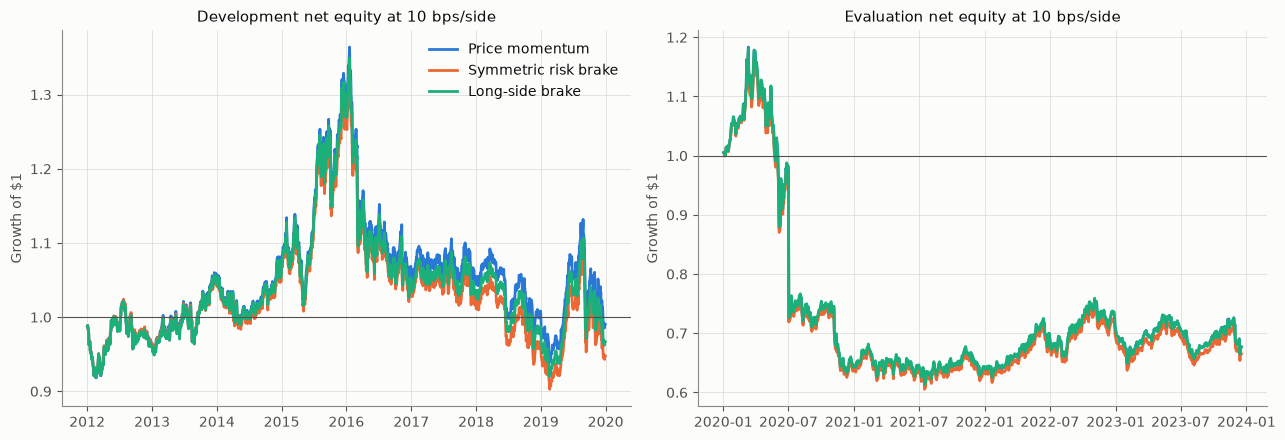

In [8]:
arm_labels = {
    "baseline": "Price momentum",
    "symmetric_brake": "Symmetric risk brake",
    "long_brake": "Long-side brake",
}
arm_colours = dict(zip(ARMS, CATEGORICAL[:3], strict=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, split in zip(axes, ("development", "evaluation"), strict=True):
    for arm in ARMS:
        daily = daily_paths[split][arm]
        equity = (1.0 + daily["net_return"]).cumprod()
        axis.plot(daily["session_date"], equity, label=arm_labels[arm], color=arm_colours[arm])
    axis.axhline(1.0, color=INK["reference"], linewidth=0.8)
    axis.set_title(f"{split.capitalize()} net equity at 10 bps/side")
    axis.set_ylabel("Growth of $1")
axes[0].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "net_equity.png", dpi=170, bbox_inches="tight")
plt.show()

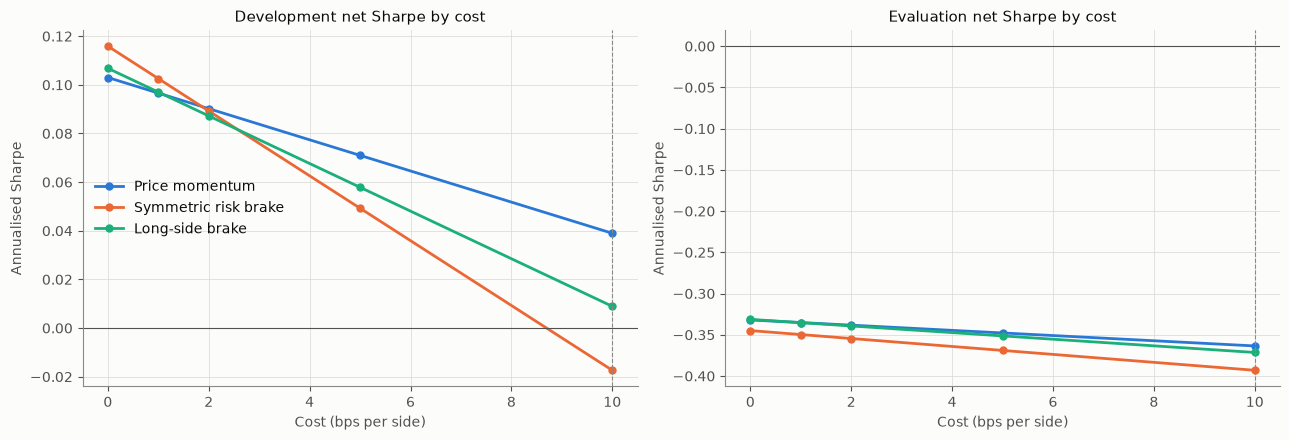

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, split in zip(axes, ("development", "evaluation"), strict=True):
    subset = cost_curve.loc[cost_curve["split"].eq(split)]
    for arm in ARMS:
        line = subset.loc[subset["arm"].eq(arm)]
        axis.plot(
            line["cost_bps_per_side"],
            line["sharpe_net"],
            marker="o",
            label=arm_labels[arm],
            color=arm_colours[arm],
        )
    axis.axhline(0.0, color=INK["reference"], linewidth=0.8)
    axis.axvline(CONFIG.cost_bps_per_side, color=INK["muted"], linewidth=0.8, linestyle="--")
    axis.set_title(f"{split.capitalize()} net Sharpe by cost")
    axis.set_xlabel("Cost (bps per side)")
    axis.set_ylabel("Annualised Sharpe")
axes[0].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_curve.png", dpi=170, bbox_inches="tight")
plt.show()

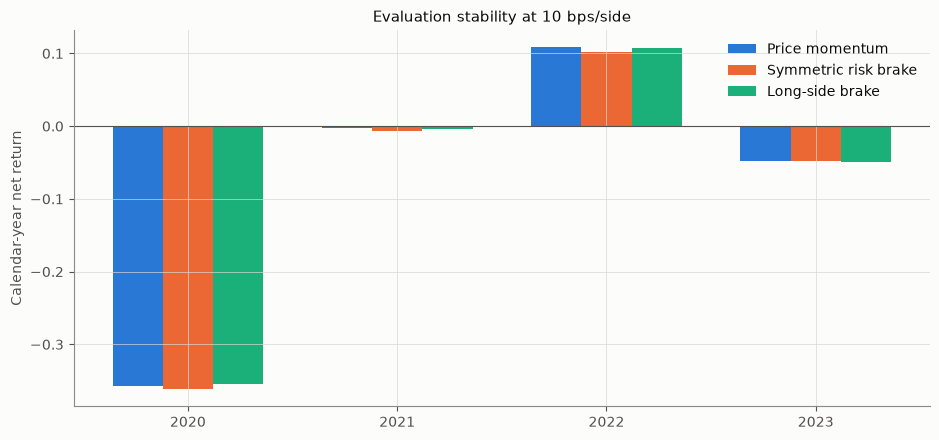

In [10]:
eval_yearly = yearly.loc[yearly["split"].eq("evaluation")]
years = sorted(eval_yearly["year"].unique())
x = np.arange(len(years))
width = 0.24
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for i, arm in enumerate(ARMS):
    values = eval_yearly.set_index(["arm", "year"]).loc[arm].reindex(years)["net_return"]
    ax.bar(x + (i - 1) * width, values, width, label=arm_labels[arm], color=arm_colours[arm])
ax.axhline(0.0, color=INK["reference"], linewidth=0.8)
ax.set_xticks(x, years)
ax.set_ylabel("Calendar-year net return")
ax.set_title("Evaluation stability at 10 bps/side")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation_yearly_return.png", dpi=170, bbox_inches="tight")
plt.show()

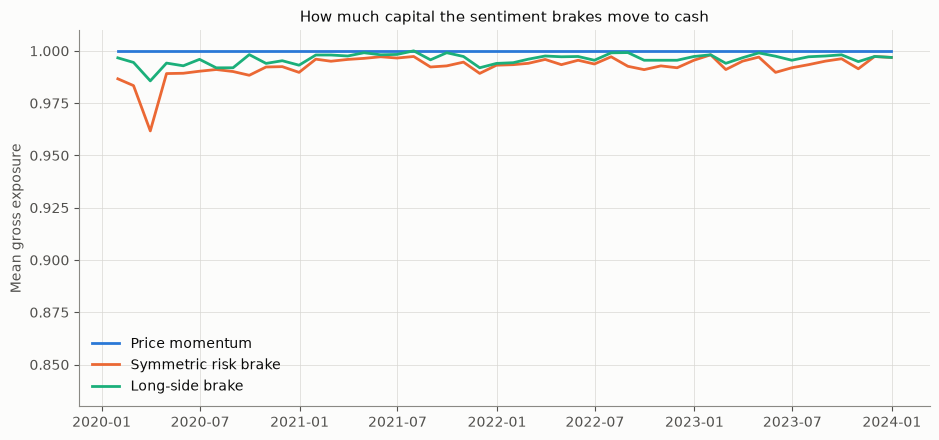

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for arm in ARMS:
    daily = daily_paths["evaluation"][arm].copy()
    monthly_gross = daily.set_index("session_date")["gross_exposure"].resample("ME").mean()
    ax.plot(monthly_gross.index, monthly_gross, label=arm_labels[arm], color=arm_colours[arm])
ax.set_ylim(0.83, 1.01)
ax.set_ylabel("Mean gross exposure")
ax.set_title("How much capital the sentiment brakes move to cash")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation_gross_exposure.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and make the decision

In [12]:
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
paired.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
activity.to_csv(OUTPUT_DIR / "overlay_activity.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
yearly.to_csv(OUTPUT_DIR / "yearly_results.csv", index=False)
formation_summary.to_csv(OUTPUT_DIR / "formation_summary.csv", index=False)
for split, arms in daily_paths.items():
    for arm, daily in arms.items():
        daily.to_parquet(OUTPUT_DIR / f"{split}_{arm}_daily.parquet", index=False)

alpha_passes = results.loc[results["alpha_gate"], ["split", "arm"]].to_dict("records")
overlay_passes = useful_overlay.loc[useful_overlay["useful_overlay_gate"], "arm"].tolist()
verdict = (
    "At least one sentiment overlay clears the predeclared useful-overlay gate."
    if overlay_passes
    else "No sentiment overlay clears the predeclared useful-overlay gate."
)
manifest = {
    "notebook": "19_fnspid_sentiment_risk_overlay",
    "built_for": "price-only momentum baseline with sparse FinBERT negative-news risk brakes",
    "analysis_status": "exploratory_frozen_before_notebook19_return_execution_2026-08-05",
    "spine": "FNSPID_only",
    "split": {
        "development_end": FROZEN_DEV_END,
        "evaluation_start": FROZEN_EVAL_START,
        "evaluation_end": str(evaluation_end.date()),
        "evaluation_previously_opened_elsewhere": True,
    },
    "design": {
        "baseline": "monthly equal-weight dollar-neutral top/bottom decile of 252-to-21-session adjusted-open momentum",
        "risk_flag": "negative_share == 1 and n >= 2",
        "overlays": ["symmetric_brake", "long_brake"],
        "neutrality": "scale both surviving legs down to the smaller gross; never lever up",
        "cost_bps_per_side": CONFIG.cost_bps_per_side,
        "cost_grid": list(COST_GRID),
        "inference": "paired 20-session circular block bootstrap; 4999 replications; BH q=0.05 over two overlays per split",
        "seed": SEED,
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "formation_summary": json.loads(formation_summary.to_json(orient="records", date_format="iso")),
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired.to_json(orient="records")),
    "useful_overlay_gate": json.loads(useful_overlay.to_json(orient="records")),
    "alpha_gate_passes": alpha_passes,
    "useful_overlay_passes": overlay_passes,
    "verdict": verdict,
    "limitations": [
        "the FNSPID cohort and 2020-2023 block have influenced prior design work",
        "fixed full-corpus symbol membership is retrospective and not a point-in-time index universe",
        "date-only FNSPID timing uses the existing conservative next-session mapping",
        "adjusted opens are split-adjusted but not dividend-adjusted",
        "negative-share is machine-labelled and not a human-validated event-risk construct",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

baseline_row = evaluation_results.loc["baseline"]
sym_row = evaluation_results.loc["symmetric_brake"]
long_row = evaluation_results.loc["long_brake"]
baseline_line = (
    f"- Evaluation baseline: net Sharpe **{baseline_row['sharpe_net']:.3f}**, "
    f"total net return **{baseline_row['total_return_net']:.2%}**, maximum drawdown "
    f"**{baseline_row['max_drawdown']:.2%}**, break-even "
    f"**{baseline_row['breakeven_bps_per_side']:.2f} bps/side**."
)
sym_line = (
    f"- Symmetric brake: net Sharpe **{sym_row['sharpe_net']:.3f}**, total net return "
    f"**{sym_row['total_return_net']:.2%}**, maximum drawdown **{sym_row['max_drawdown']:.2%}**, "
    f"paired improvement **{evaluation_paired.loc['symmetric_brake', 'mean_difference'] * 10_000:.3f} "
    f"bps/day** (BH reject: **{bool(evaluation_paired.loc['symmetric_brake', 'bh_reject_q05'])}**)."
)
long_line = (
    f"- Long-side brake: net Sharpe **{long_row['sharpe_net']:.3f}**, total net return "
    f"**{long_row['total_return_net']:.2%}**, maximum drawdown **{long_row['max_drawdown']:.2%}**, "
    f"paired improvement **{evaluation_paired.loc['long_brake', 'mean_difference'] * 10_000:.3f} "
    f"bps/day** (BH reject: **{bool(evaluation_paired.loc['long_brake', 'bh_reject_q05'])}**)."
)
display(
    Markdown(
        f"""### Decision

**{verdict}**

{baseline_line}
{sym_line}
{long_line}

An overlay that merely lowers exposure is not called alpha. Promotion requires
the declared net-return, cost and drawdown gate; otherwise the honest result is
a bounded falsification of sentiment risk-sizing on this price baseline.
"""
    )
)

### Decision

**No sentiment overlay clears the predeclared useful-overlay gate.**

- Evaluation baseline: net Sharpe **-0.364**, total net return **-32.27%**, maximum drawdown **-48.36%**, break-even **-105.47 bps/side**.
- Symmetric brake: net Sharpe **-0.393**, total net return **-33.48%**, maximum drawdown **-48.31%**, paired improvement **-0.204 bps/day** (BH reject: **False**).
- Long-side brake: net Sharpe **-0.371**, total net return **-32.37%**, maximum drawdown **-48.08%**, paired improvement **-0.035 bps/day** (BH reject: **False**).

An overlay that merely lowers exposure is not called alpha. Promotion requires
the declared net-return, cost and drawdown gate; otherwise the honest result is
a bounded falsification of sentiment risk-sizing on this price baseline.
